# 4.1  Crear modelos para cada período

## EDA 


--- Periodo: 2009 ---

Tamaño del vocabulario único: 801
Frecuencia total de palabras: 1715
Frecuencia media de las palabras (BCa): 2.14 (IC 95%: 1.97, 2.36)
['articulo' 'dea' 'persona' 'lugar' 'publico' 'cardiaco' 'ley' 'deber'
 'proyecto' 'desfibrilador']


--- Periodo: 2014 ---

Tamaño del vocabulario único: 686
Frecuencia total de palabras: 1850
Frecuencia media de las palabras (BCa): 2.70 (IC 95%: 2.50, 2.94)
['articulo' 'programa' 'deportivo' 'cardiaco' 'actividad' 'nino' 'causa'
 'fisico' 'joven' 'persona']


--- Periodo: 2019 ---

Tamaño del vocabulario único: 694
Frecuencia total de palabras: 1893
Frecuencia media de las palabras (BCa): 2.73 (IC 95%: 2.53, 2.98)
['deportivo' 'actividad' 'articulo' 'nino' 'fisico' 'programa' 'deber'
 'establecimiento' 'ley' 'prevencion']




In [1]:
# Importar librerias
from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

from tqdm import tqdm
tqdm.pandas()

In [10]:
# Configurar path
### CONFIGURACION
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") + '/muerte_subita/' # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)


In [11]:
# LEER OBJETO PARA DETECTAR CAMBIOS SEMANTICOS
with open(RESULTADOS_DIR + 'periodo_5anios_df.pkl', 'rb') as file: 
    PER5anios_df = pickle.load(file)

In [4]:
PER5anios_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Periodo_5anios      3 non-null      int64 
 1   Título normalizado  3 non-null      object
 2   corpus              3 non-null      object
dtypes: int64(1), object(2)
memory usage: 204.0+ bytes


## Estrategias para Entrenar Embeddings en Corpus Pequeños por Periodo:
* Count-based Methods
* Word2Vec (CBOW o Skip-gram) con parámetros ajustados

### 1- Crear modelo Word2Vec 


**Consideraciones**

Con parámetros ajustados

* sg : para el algoritmo de entrenamiento considerar Skip-Gram (SG=1). Skip-Gram intenta predecir las palabras del contexto dada una palabra objetivo, lo que puede ser más efectivo para aprender representaciones cuando cada palabra tiene menos ocurrencias.
* min_count: Un valor bajo (ejemplo 1 o 2) para no descartar muchas palabras debido a su baja frecuencia.
* vector_size: Una dimensionalidad baja del embedding (ejemplo 50-100) para evitar el sobreajuste con pocos datos.
* window: Un tamaño de ventana pequeño (ejemplo 2,5,8) para enfocarse en el contexto inmediato.
* epochs: Un número moderado de épocas de entrenamiento para evitar el sobreajuste. Entrenar con más épocas permite que el modelo pase más veces por los datos, lo que puede ser crucial cuando la cantidad de datos es pequeña para que las representaciones converjan mejor.

* Desactivar o reducir el negative_sampling: Esta técnica requiere más datos para ser efectiva.
* worker: controlar que el entrenamiento se realice en un solo hilo de forma secuencial. Esto elimina la variabilidad introducida por el procesamiento paralelo y asegura que los datos se procesen siempre en el mismo orden relativo en cada época. 

Inestabilidad: Los embeddings entrenados en corpus tan pequeños pueden ser inestables y sensibles a las particularidades de los datos. Por lo que es importante ser cautelosos con el uso de los resultados.

Determinismo: Al fijar la semilla aleatoria (seed en Word2Vec y np.random.seed()), y con un procesamiento secuencial (workers=1), el proceso de inicialización de los pesos y las actualizaciones durante el entrenamiento se vuelven "deterministas", lo que lleva a resultados idénticos en cada ejecución.

Entrenamiento por Periodo:

Entrena un modelo de embedding separado para cada periodo para aplicar en los enfoques para analizar cambios semanticos entre los diferentes momentos temporales.

En el contexto de un corpus pequeño para entrenar Word2Vec, la limitación en la cantidad de datos actúa como una forma de regularización implícita para aprender representaciones de palabras basadas en las co-ocurrencias limitadas que observa.



Entrenar embeddings Word2Vec para cada período.
Usamos Word2Vec con 

```
Word2Vec(
    sentences = sentences,
    vector_size = 50,       # menor dimensión para evitar sobreajuste
    window= 5 ,             # cada par palabra-contexto se verá con más frecuencia, ayudando al modelo a aprender asociaciones más robustas con los datos disponibles (contexto típico). Sin embargo, es posible que se necesites experimentar con otros valores como 2 o 10  para ver cuál produce los embeddings más coherentes.
    min_count=2,    # La mayoría de las palabras en período de 5 años tienen baja frecuencia de ocurrencia concentran alrededor de frecuencia=2. 
    workers= 1,
    sg=1,                 # usar Skip-Gram, funciona mejor en corpus pequeños
    epochs=50             # entrenar más veces para compensar pocos datos
)
```

In [12]:
from gensim.models import Word2Vec
#https://radimrehurek.com/gensim/models/word2vec.html

def entrenar_word2vec(sentencias, size=50, window=5, min_count=2,  w=1, s=1, e=50, seed=1):
    return Word2Vec(sentencias, vector_size=size, window=window, min_count=min_count, workers=w, sg= s, epochs=e, seed=seed)


In [13]:
def pares_primer_paso(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]

In [7]:
anios5_list = sorted(PER5anios_df['Periodo_5anios'].to_list())
anios5_list
anios5_pairs = pares_primer_paso(anios5_list)
anios5_pairs


[(2009, 2014), (2014, 2019)]

In [14]:
PER5anios_df['corpus'][0][:3] # 2009

[['proyecto',
  'senado',
  'camara',
  'diputado',
  'ley',
  'prevencion',
  'espacio',
  'acceso',
  'publico',
  'capitulo',
  'disposicion',
  'general',
  'articulo',
  'objeto',
  'objeto',
  'presente',
  'ley',
  'regular',
  'sistema',
  'prevencion',
  'integral',
  'evento',
  'espacio',
  'publico',
  'privado',
  'acceso',
  'publico',
  'articulo',
  'definicion',
  'efecto',
  'ley',
  'considerar',
  'resucitacion',
  'cardiopulmonar',
  'rcp',
  'maniobra',
  'cabo',
  'persona',
  'caso',
  'detencion',
  'circulacion',
  'sangre',
  'destinado',
  'oxigenacion',
  'inmediato',
  'organo',
  'vital',
  'desfibrilacion',
  'maniobra',
  'rcp',
  'incluir',
  'desfibrilador',
  'externo',
  'automatico',
  'dea',
  'desfibrilador',
  'externo',
  'automatico',
  'dea',
  'dispositivo',
  'portatil',
  'utilizado',
  'estimular',
  'electricamente',
  'corazon',
  'persona',
  'paro',
  'cardiaco',
  'espacio',
  'publico',
  'privado',
  'acceso',
  'publico',
  'lugar

In [15]:
# Entrenar modelos de Word2Vec para cada período
i = 1 # iteración
modelos = [] # Cargamos modelos
for anios5, corpus in tqdm(zip(PER5anios_df['Periodo_5anios'], PER5anios_df['corpus'])):
    print(anios5)
    print(len(corpus))
    modelo = entrenar_word2vec(corpus, size=50, window=5, min_count=2, w=1, s=1, e=50, seed=1)
    modelos.append(modelo)
    


0it [00:00, ?it/s]

2009
2


1it [00:00,  3.82it/s]

2014
3


2it [00:00,  3.42it/s]

2019
3


3it [00:00,  3.35it/s]


In [17]:
# https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.most_similar.html
palabras_altaFrec = ["nino", "actividad", "deportivo", "rcp"]

In [18]:
for palabra in palabras_altaFrec:
    print("--------------")
    print(palabra)
    print("--------------")
    for anios5 ,modelo in tqdm(zip(['2009','2014','2019'], modelos)):
        print(anios5,)
        print("Top 10 vecinos")
        if palabra in modelo.wv.index_to_key:
            k_vecinos_10 = modelo.wv.most_similar(palabra, topn=10) # similitud coseno
            print([pal for pal, coseno in k_vecinos_10])
            print(k_vecinos_10)
            print('\n')
        else: 
            print("Esta palabra no aparece en modelo", palabra)


--------------
nino
--------------


3it [00:00, 282.24it/s]


2009
Top 10 vecinos
Esta palabra no aparece en modelo nino
2014
Top 10 vecinos
['adolescente', 'premonitorio', 'obesidad', 'sedentarismo', 'aumento', 'bienestar', 'redundar', 'mayoria', 'escolar', 'frecuente']
[('adolescente', 0.9347888827323914), ('premonitorio', 0.8671322464942932), ('obesidad', 0.8445786237716675), ('sedentarismo', 0.8404456377029419), ('aumento', 0.8316933512687683), ('bienestar', 0.8238226771354675), ('redundar', 0.8158049583435059), ('mayoria', 0.8148512244224548), ('escolar', 0.8053489923477173), ('frecuente', 0.7873067259788513)]


2019
Top 10 vecinos
['aplicar', 'adolescente', 'premonitorio', 'mayoria', 'baja', 'rango', 'sufrir', 'presentar', 'cercano', 'mama']
[('aplicar', 0.813767671585083), ('adolescente', 0.8105055689811707), ('premonitorio', 0.808127224445343), ('mayoria', 0.8045111894607544), ('baja', 0.8035207390785217), ('rango', 0.8005584478378296), ('sufrir', 0.7921780943870544), ('presentar', 0.7863082885742188), ('cercano', 0.7751709818840027), ('m

3it [00:00, 983.19it/s]


2009
Top 10 vecinos
['elemento', 'deportivo', 'funcion', 'trabajo', 'asistir', 'pais', 'impulsar', 'imponer', 'evento', 'equipo']
[('elemento', 0.8985735177993774), ('deportivo', 0.8895514011383057), ('funcion', 0.8846318125724792), ('trabajo', 0.8741085529327393), ('asistir', 0.8726627826690674), ('pais', 0.8720874190330505), ('impulsar', 0.8661140203475952), ('imponer', 0.8568557500839233), ('evento', 0.8540771007537842), ('equipo', 0.8539460897445679)]


2014
Top 10 vecinos
['sedentaria', 'educativo', 'ludicar', 'recreativa', 'extraescolar', 'competitivo', 'promocion', 'iniciacion', 'evidente', 'colegio']
[('sedentaria', 0.872105062007904), ('educativo', 0.8659034967422485), ('ludicar', 0.8636674284934998), ('recreativa', 0.8630913496017456), ('extraescolar', 0.8488795161247253), ('competitivo', 0.8412965536117554), ('promocion', 0.8092426061630249), ('iniciacion', 0.8033928275108337), ('evidente', 0.7959363460540771), ('colegio', 0.7931212186813354)]


2019
Top 10 vecinos
['ludicar

3it [00:00, 1497.25it/s]


2009
Top 10 vecinos
['moderno', 'pais', 'ejemplo', 'disponer', 'actividad', 'asistir', 'dictar', 'imponer', 'airlin', 'cabo']
[('moderno', 0.9388644695281982), ('pais', 0.9272773861885071), ('ejemplo', 0.9164599180221558), ('disponer', 0.8976174592971802), ('actividad', 0.8895513415336609), ('asistir', 0.8815839886665344), ('dictar', 0.8738897442817688), ('imponer', 0.8729341626167297), ('airlin', 0.8678784370422363), ('cabo', 0.8652523756027222)]


2014
Top 10 vecinos
['practica', 'vigente', 'participar', 'sumo', 'considerar', 'iniciacion', 'reglado', 'organizado', 'superior', 'nacional']
[('practica', 0.8660587668418884), ('vigente', 0.8379232883453369), ('participar', 0.8342542052268982), ('sumo', 0.8310588598251343), ('considerar', 0.824374258518219), ('iniciacion', 0.7944051623344421), ('reglado', 0.7857007384300232), ('organizado', 0.7838543653488159), ('superior', 0.7752610445022583), ('nacional', 0.7687180042266846)]


2019
Top 10 vecinos
['iniciacion', 'servicio', 'club', 'alo

3it [00:00, 3011.71it/s]

2009
Top 10 vecinos
['externo', 'automatico', 'sobrevida', 'maniobra', 'resucitacion', 'comunidad', 'cardiopulmonar', 'utilizar', 'basica', 'basico']
[('externo', 0.959816038608551), ('automatico', 0.9578260183334351), ('sobrevida', 0.946401059627533), ('maniobra', 0.9351107478141785), ('resucitacion', 0.9304333925247192), ('comunidad', 0.9193345308303833), ('cardiopulmonar', 0.9166215062141418), ('utilizar', 0.9121965765953064), ('basica', 0.9107441902160645), ('basico', 0.9099327325820923)]


2014
Top 10 vecinos
Esta palabra no aparece en modelo rcp
2019
Top 10 vecinos
Esta palabra no aparece en modelo rcp


#### Entrenamiento por periodo

* Estabilidad del Embedding (Intra-Periodo): Para cada combinación de hiperparámetros y para cada periodo, entrenar el modelo varias veces (por ejemplo, 5-10 veces) con diferentes semillas aleatorias (pero manteniendo fijo el resto de los hiperparámetros). Luego, mide la similitud (coseno) entre los embeddings de las palabras clave (las palabras que esperas que cambien semánticamente o las palabras de alta frecuencia) a través de estas múltiples ejecuciones. Una mayor similitud promedio indica una mayor estabilidad para esa configuración de hiperparámetros dentro de un periodo.
* Selección de los Mejores Hiperparámetros: El "mejor" conjunto de hiperparámetros será aquel que logre un buen equilibrio entre. 
    * Estabilidad: Los embeddings de las palabras clave deben ser consistentes a través de múltiples ejecuciones con la misma configuración.
    * Calidad Semántica: Los vecinos más cercanos. Evaluación del cambio en los vecinos semánticos de cada palabra a través de métricas como Jaccard.

Espacio de Búsqueda

In [19]:
 # Define el espacio de búsqueda de hiperparámetros como una distribución
    
param_grid = {
    'vector_size': [50, 100],
    'window': [2,5,10],
    'epochs': [30, 50],
}
param_grid

{'vector_size': [50, 100], 'window': [2, 5, 10], 'epochs': [30, 50]}

Función de Evaluación: para explorar la estabilidad intra-periodo.
La similitud coseno promedio entre los embeddings de las palabras clave en diferentes ejecuciones es una métrica simple. 

In [20]:
from sklearn.model_selection import ParameterSampler
from gensim.models import Word2Vec
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import random

In [21]:
import numpy as np
import random as rn

def evaluar_estabilidad_tradicional(corpus, params_fijos, semillas, palabras_clave=['nacional', 'programa', 'salud']):
    """
    Evalúa la estabilidad intra-periodo de Word2Vec entrenando múltiples veces
    con diferentes semillas para un conjunto fijo de hiperparámetros.

    Args:
        corpus (list): El corpus para un período específico.
        params_fijos (dict): Diccionario de hiperparámetros fijos para Word2Vec.
        semillas (list): Lista de semillas aleatorias para el entrenamiento.
        palabras_clave (list): Lista de palabras clave para evaluar la estabilidad.

    Returns:
        dict: Diccionario con la estabilidad promedio por palabra clave.
    """
    vocabulario = set()
    for oracion in corpus:
        vocabulario.update(oracion)

    estabilidades_palabras = {palabra: [] for palabra in palabras_clave if palabra in vocabulario}
    embeddings_por_semilla = {semilla: {} for semilla in semillas}

    for semilla in semillas:
        np.random.seed(semilla)
        rn.seed(semilla)
        try:
            params = params_fijos.copy()
            params['seed'] = semilla
            model = Word2Vec(sentences=corpus, **params, workers=1, sg=1) # min_count=2
            for palabra in palabras_clave:
                if palabra in model.wv:
                    embeddings_por_semilla[semilla][palabra] = model.wv[palabra]
        except Exception as e:
            print(f"Error al entrenar con semilla {semilla} y parámetros {params_fijos}: {e}")

    for palabra in estabilidades_palabras:
        vectores_palabra = [embeddings_por_semilla[semilla].get(palabra) for semilla in semillas if embeddings_por_semilla[semilla].get(palabra) is not None]
        if len(vectores_palabra) >= 2:
            for i in range(len(vectores_palabra)):
                for j in range(i + 1, len(vectores_palabra)):
                    sim = cosine_similarity([vectores_palabra[i]], [vectores_palabra[j]])[0][0]
                    estabilidades_palabras[palabra].append(sim)

    return {palabra: np.mean(sims) if sims else 0.0 for palabra, sims in estabilidades_palabras.items()}


##### Para min_count=2

In [22]:
semillas_evaluacion = [42, 123, 456]
resultados_estabilidad_por_periodo = {}

# Prepara tus corpus por período en un diccionario
corpus_por_periodo = {}
periodos = PER5anios_df['Periodo_5anios'].tolist()
corpus_list = PER5anios_df['corpus'].tolist()
for periodo, corpus in zip(periodos, corpus_list):
    corpus_por_periodo[periodo] = corpus

Calcula la estabilidad de la representación de cada palabra clave midiendo cuán similares son sus embeddings cuando se entrenan múltiples veces con los mismos hiperparámetros pero con diferentes inicializaciones aleatorias (semillas). Una mayor similitud coseno promedio indica una mayor estabilidad de la representación de esa palabra para la configuración de hiperparámetros dada.

In [23]:
estabilidad = evaluar_estabilidad_tradicional(corpus_por_periodo[2009], {'vector_size': 50, 'window': 2, 'epochs': 30}, semillas_evaluacion, palabras_altaFrec)
print(estabilidad)
estabilidad = evaluar_estabilidad_tradicional(corpus_por_periodo[2009], {'vector_size': 50, 'window': 2, 'epochs': 30}, semillas_evaluacion, palabras_altaFrec)
print(estabilidad)
estabilidad = evaluar_estabilidad_tradicional(corpus_por_periodo[2009], {'vector_size': 100, 'window': 2, 'epochs': 30}, semillas_evaluacion, palabras_altaFrec)
print(estabilidad)

{'actividad': 0.0, 'deportivo': 0.0, 'rcp': 0.0}
{'actividad': 0.0, 'deportivo': 0.0, 'rcp': 0.0}
{'actividad': 0.0, 'deportivo': 0.0, 'rcp': 0.0}


random_state=42: Este argumento establece la semilla aleatoria para el generador de números aleatorios utilizado por RandomizedSearchCV para muestrear las combinaciones de parámetros. Fijar una random_state garantiza que la secuencia de combinaciones de parámetros que se prueban sea la misma en cada ejecución del código. Esto es importante para la reproducibilidad de la búsqueda de hiperparámetros

In [24]:
from itertools import product

claves_parametros = list(param_grid.keys())

for periodo, corpus in corpus_por_periodo.items():
    print(f"\nEvaluando estabilidad para el período: {periodo}")
    resultados_estabilidad_por_periodo[periodo] = {}
    
    for combinacion in tqdm(product(*param_grid.values()), total=np.prod([len(v) for v in param_grid.values()])):
        params_fijos = dict(zip(claves_parametros, combinacion))
        estabilidad = evaluar_estabilidad_tradicional(corpus, params_fijos, semillas_evaluacion,palabras_altaFrec)
        
        estabilidad_promedio = np.mean(list(estabilidad.values())) if estabilidad else 0.0
        resultados_estabilidad_por_periodo[periodo][tuple(params_fijos.items())] = estabilidad_promedio
        print(f"  Parámetros: {params_fijos}, Estabilidad promedio: {estabilidad_promedio:.4f}, Estabilidad por palabra: {estabilidad}")

print("\nResultados de estabilidad por período y parámetros:")
for periodo, resultados in resultados_estabilidad_por_periodo.items():
    print(f"\nPeríodo: {periodo}")
    for params, estabilidad in sorted(resultados.items(), key=lambda item: item[1], reverse=True):
        print(f"  Parámetros: {dict(params)}, Estabilidad promedio: {estabilidad:.4f}")




Evaluando estabilidad para el período: 2009


  8%|██████▉                                                                            | 1/12 [00:00<00:01,  6.27it/s]

  Parámetros: {'vector_size': 50, 'window': 2, 'epochs': 30}, Estabilidad promedio: 0.0000, Estabilidad por palabra: {'actividad': 0.0, 'deportivo': 0.0, 'rcp': 0.0}


 25%|████████████████████▊                                                              | 3/12 [00:00<00:01,  5.09it/s]

  Parámetros: {'vector_size': 50, 'window': 2, 'epochs': 50}, Estabilidad promedio: 0.0000, Estabilidad por palabra: {'actividad': 0.0, 'deportivo': 0.0, 'rcp': 0.0}
  Parámetros: {'vector_size': 50, 'window': 5, 'epochs': 30}, Estabilidad promedio: 0.0000, Estabilidad por palabra: {'actividad': 0.0, 'deportivo': 0.0, 'rcp': 0.0}


...

  Parámetros: {'vector_size': 100, 'window': 5, 'epochs': 50}, Estabilidad promedio: -0.0718, Estabilidad por palabra: {'nino': -0.06633162, 'actividad': -0.06893223, 'deportivo': -0.08024901}


 92%|███████████████████████████████████████████████████████████████████████████▏      | 11/12 [00:03<00:00,  3.49it/s]

  Parámetros: {'vector_size': 100, 'window': 10, 'epochs': 30}, Estabilidad promedio: -0.0955, Estabilidad por palabra: {'nino': -0.11710326, 'actividad': -0.07331339, 'deportivo': -0.09613622}


100%|██████████████████████████████████████████████████████████████████████████████████| 12/12 [00:03<00:00,  3.33it/s]

  Parámetros: {'vector_size': 100, 'window': 10, 'epochs': 50}, Estabilidad promedio: -0.0879, Estabilidad por palabra: {'nino': -0.12181542, 'actividad': -0.064687766, 'deportivo': -0.07732764}

Resultados de estabilidad por período y parámetros:

Período: 2009
  Parámetros: {'vector_size': 50, 'window': 2, 'epochs': 30}, Estabilidad promedio: 0.0000
  Parámetros: {'vector_size': 50, 'window': 2, 'epochs': 50}, Estabilidad promedio: 0.0000
  Parámetros: {'vector_size': 50, 'window': 5, 'epochs': 30}, Estabilidad promedio: 0.0000
  Parámetros: {'vector_size': 50, 'window': 5, 'epochs': 50}, Estabilidad promedio: 0.0000
  Parámetros: {'vector_size': 50, 'window': 10, 'epochs': 30}, Estabilidad promedio: 0.0000
  Parámetros: {'vector_size': 50, 'window': 10, 'epochs': 50}, Estabilidad promedio: 0.0000
  Parámetros: {'vector_size': 100, 'window': 2, 'epochs': 30}, Estabilidad promedio: 0.0000
  Parámetros: {'vector_size': 100, 'window': 2, 'epochs': 50}, Estabilidad promedio: 0.0000
  Par

La "Estabilidad promedio"  da una visión general del rendimiento de un conjunto de parámetros. Un valor más alto indica que, en general, los embeddings tienden a ser más consistentes a través de diferentes inicializaciones.

In [25]:
resultados_estabilidad_por_periodo

{2009: {(('vector_size', 50), ('window', 2), ('epochs', 30)): 0.0,
  (('vector_size', 50), ('window', 2), ('epochs', 50)): 0.0,
  (('vector_size', 50), ('window', 5), ('epochs', 30)): 0.0,
  (('vector_size', 50), ('window', 5), ('epochs', 50)): 0.0,
  (('vector_size', 50), ('window', 10), ('epochs', 30)): 0.0,
  (('vector_size', 50), ('window', 10), ('epochs', 50)): 0.0,
  (('vector_size', 100), ('window', 2), ('epochs', 30)): 0.0,
  (('vector_size', 100), ('window', 2), ('epochs', 50)): 0.0,
  (('vector_size', 100), ('window', 5), ('epochs', 30)): 0.0,
  (('vector_size', 100), ('window', 5), ('epochs', 50)): 0.0,
  (('vector_size', 100), ('window', 10), ('epochs', 30)): 0.0,
  (('vector_size', 100), ('window', 10), ('epochs', 50)): 0.0},
 2014: {(('vector_size', 50),
   ('window', 2),
   ('epochs', 30)): -0.003304116355138831,
  (('vector_size', 50), ('window', 2), ('epochs', 50)): -0.0042335111065767705,
  (('vector_size', 50), ('window', 5), ('epochs', 30)): -0.03789406921714544,
  

In [26]:
datos = []
for periodo, configs in resultados_estabilidad_por_periodo.items():
    for parametros, valor in configs.items():
        config_dict = {k: v for k, v in parametros}
        config_dict['periodo'] = periodo
        config_dict['valor'] = valor
        datos.append(config_dict)

df_resultados = pd.DataFrame(datos)
df_resultados.to_csv(RESULTADOS_DIR+'/archivos_out/Word2Vec_palabrasMasFrc.csv', index=False)

df_resultados

,vector_size,window,epochs,periodo,valor
0,50,2,30,2009,0.000000
1,50,2,50,2009,0.000000
2,50,5,30,2009,0.000000
3,50,5,50,2009,0.000000
4,50,10,30,2009,0.000000
5,50,10,50,2009,0.000000
6,100,2,30,2009,0.000000
7,100,2,50,2009,0.000000
8,100,5,30,2009,0.000000
9,100,5,50,2009,0.000000


Cálculo de la Estabilidad Promedio General

In [27]:
df_resultados.groupby(['vector_size', 'window', 'epochs'])['valor'].mean().reset_index().sort_values('valor', ascending=False)

,vector_size,window,epochs,valor
1,50,2,50,-0.003674
0,50,2,30,-0.004497
3,50,5,50,-0.006793
5,50,10,50,-0.010901
2,50,5,30,-0.011623
4,50,10,30,-0.026511
11,100,10,50,-0.034546
9,100,5,50,-0.039075
7,100,2,50,-0.040330
6,100,2,30,-0.040515


Análisis por Período

Examina los resultados para cada período individualmente. Para cada período, identifica las combinaciones de hiperparámetros que obtuvieron las mejores puntuaciones de estabilidad.

In [28]:
mejores_por_periodo = df_resultados.loc[df_resultados.groupby('periodo')['valor'].idxmax()].reset_index(drop=True)
mejores_por_periodo.sort_values('valor', ascending=False)

,vector_size,window,epochs,periodo,valor
2,50,5,50,2019,0.019507
0,50,2,30,2009,0.000000
1,50,2,30,2014,-0.003304


Interpretación de los Resultados (Asumiendo que valores más altos son mejores):

* En la "Estabilidad promedio general": Las combinaciones de parámetros que aparecen en la parte superior son las que, en promedio, produjeron los embeddings más estables a través de tus diferentes períodos. Estos son buenos candidatos para ser tus parámetros "óptimos".
* En los "Mejores parámetros por período": Esto te da una idea de qué funcionó mejor en cada contexto temporal específico. Si una combinación de parámetros aparece como la mejor o entre las mejores en varios períodos, es una señal fuerte de su robustez.

##### Para una muestra aleatorio de vocabularios

In [30]:

def evaluar_estabilidad_intra_periodo(corpus_por_periodo,param_grid,semillas_evaluacion,palabras_muestra,nombre_csv):

    claves_parametros = list(param_grid.keys())
    for periodo, corpus in corpus_por_periodo.items():
        print(f"\nEvaluando estabilidad para el período: {periodo}")
        resultados_estabilidad_por_periodo[periodo] = {}
        
        for combinacion in tqdm(product(*param_grid.values()), total=np.prod([len(v) for v in param_grid.values()])):
            params_fijos = dict(zip(claves_parametros, combinacion))
            estabilidad = evaluar_estabilidad_tradicional(corpus, params_fijos, semillas_evaluacion,palabras_muestra)
            estabilidad_promedio = np.mean(list(estabilidad.values())) if estabilidad else 0.0
            resultados_estabilidad_por_periodo[periodo][tuple(params_fijos.items())] = estabilidad_promedio
            #print(f"  Parámetros: {params_fijos}, Estabilidad promedio: {estabilidad_promedio:.4f}, Estabilidad por palabra: {estabilidad}")
    datos = []
    for periodo, configs in resultados_estabilidad_por_periodo.items():
        for parametros, valor in configs.items():
            config_dict = {k: v for k, v in parametros}
            config_dict['periodo'] = periodo
            config_dict['valor'] = valor
            datos.append(config_dict)

    df_resultados = pd.DataFrame(datos)
    df_resultados.to_csv(RESULTADOS_DIR+'/archivos_out/'+nombre_csv+'.csv', index=False)

    
    # Ordenar por estabilidad promedio general (mayor a menor)
    print("\nEstabilidad promedio general por combinación de parámetros:")
    display(df_resultados.groupby(['vector_size', 'window', 'epochs','min_count'])['valor'].mean().reset_index().sort_values('valor', ascending=False))
    print("\nMejores parámetros por período:")
    mejores_por_periodo = df_resultados.loc[df_resultados.groupby('periodo')['valor'].idxmax()].reset_index(drop=True)
    display(mejores_por_periodo.sort_values('valor', ascending=False))
    return df_resultados
    

In [31]:
vocabulario = set()
for periodo, corpus in corpus_por_periodo.items():
    for oracion in corpus:
        vocabulario.update(oracion)
print('Vocabulario', len(vocabulario))


Vocabulario 1220


In [32]:
import random

# Número de palabras a seleccionar
numero_de_palabras = 100

# Seleccionar la muestra aleatoria
muestra_aleatoria = random.sample(list(vocabulario), numero_de_palabras)

# Imprimir la muestra
print(muestra_aleatoria)

['aparato', 'kraft', 'cincuenta', 'cien', 'cine', 'conciencia', 'corresponderan', 'enlace', 'envenenamiento', 'toyota', 'resultado', 'disparador', 'ano', 'espanol', 'beneficio', 'certificacion', 'constitucion', 'competidor', 'conformacion', 'sencillo', 'dilatacion', 'fomentar', 'asistir', 'depo', 'creasar', 'solucion', 'motorola', 'salvar', 'hotel', 'alitalia', 'fertil', 'limitado', 'subitar', 'tercio', 'sedimento', 'hipertrofico', 'contribucion', 'capitulo', 'reglamentaro', 'cardiologica', 'efecto', 'cuestion', 'isquemia', 'adecuado', 'violento', 'evaluacion', 'industria', 'elemento', 'ataque', 'recinto', 'amplio', 'equipado', 'conocido', 'maestro', 'falta', 'prestir', 'belgrano', 'externo', 'aberrante', 'practica', 'recuperacion', 'ciento', 'causar', 'iar', 'terma', 'actualmente', 'contemplar', 'oms', 'desarrollar', 'adquirido', 'encuesta', 'electrocardiograma', 'resucitacion', 'subita', 'supervision', 'explicar', 'pulmonar', 'actuar', 'cardiologico', 'instalacion', 'sociedad', 'esti

In [34]:
# Abre el archivo en modo de escritura
with open(RESULTADOS_DIR+'/archivos_out/muestra_aleatoria_100_word2vec.csv', "w") as archivo:
    # Itera sobre la lista y escribe cada elemento en una nueva línea
    for elemento in muestra_aleatoria:
        archivo.write(elemento + "\n")

In [37]:

param_grid = {
    'vector_size': [50,80,100],
    'window': [5,8,9,10],
    'epochs': [50,100,150],
    'min_count':[2,5,8]
}

palabras_muestra = muestra_aleatoria
evaluar_estabilidad_intra_periodo(corpus_por_periodo,param_grid,semillas_evaluacion,palabras_muestra,'Word2Vec_muestra100_epochsSize_min_count')



Evaluando estabilidad para el período: 2009


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [02:13<00:00,  1.24s/it]



Evaluando estabilidad para el período: 2014


100%|████████████████████████████████████████████████████████████████████████████████| 108/108 [02:52<00:00,  1.59s/it]



Evaluando estabilidad para el período: 2019


...


Estabilidad promedio general por combinación de parámetros:


,vector_size,window,epochs,min_count,valor
44,80,5,150,8,0.002409
2,50,5,50,8,0.001999
26,50,9,150,8,0.001765
71,80,10,150,8,0.001685
8,50,5,150,8,0.001665
...,...,...,...,...,...
81,100,8,50,2,-0.019077
36,80,5,50,2,-0.019479
90,100,9,50,2,-0.019632
0,50,5,50,2,-0.020525



Mejores parámetros por período:


,vector_size,window,epochs,min_count,periodo,valor
1,80,9,150,8,2014,0.004203
0,50,9,50,8,2009,0.003486
2,100,8,150,8,2019,0.003177


,vector_size,window,epochs,min_count,periodo,valor
0,50,5,50,2,2009,-0.021677
1,50,5,50,5,2009,-0.011115
2,50,5,50,8,2009,0.002058
3,50,5,100,2,2009,-0.014233
4,50,5,100,5,2009,-0.010729
...,...,...,...,...,...,...
319,100,10,100,5,2019,-0.006214
320,100,10,100,8,2019,0.002852
321,100,10,150,2,2019,-0.016306
322,100,10,150,5,2019,-0.006154


#### Modificando Min_count

In [38]:
resultado_df = pd.read_csv(RESULTADOS_DIR+'/archivos_out/Word2Vec_muestra100_epochsSize_min_count.csv')
print("\nMejores parámetros por período:")
mejores_por_periodo = resultado_df.loc[resultado_df.groupby('periodo')['valor'].idxmax()].reset_index(drop=True)
display(mejores_por_periodo.sort_values('valor', ascending=False))



Mejores parámetros por período:


,vector_size,window,epochs,min_count,periodo,valor
1,80,9,150,8,2014,0.004203
0,50,9,50,8,2009,0.003486
2,100,8,150,8,2019,0.003177


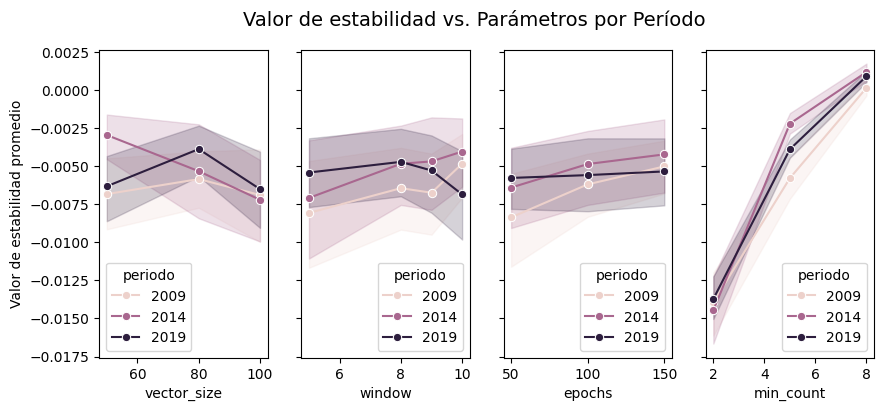

In [39]:
# Suponiendo que ya tienes tu DataFrame 'resultado_df' con las columnas de parámetros separadas

parametros = ['vector_size', 'window', 'epochs', 'min_count']

num_columnas = len(parametros)
fig, axes = plt.subplots(1, num_columnas, figsize=(10, 4), sharey=True)
fig.suptitle('Valor de estabilidad vs. Parámetros por Período', fontsize=14)
#plt.subplots_adjust(hspace=0.4, wspace=0.3)

for i, param in enumerate(parametros):
    ax = axes[i]
    sns.lineplot(data=resultado_df, x=param, y='valor', marker='o', ax=ax, hue='periodo') #estimator='mean'
    #ax.set_title(f'Período {periodo}')
    ax.set_xlabel(param)
    ax.set_ylabel('Valor de estabilidad promedio' if i == 0 else '')  # Etiqueta 'Valor' solo en la primera columna
    ax.grid(False)

plt.show()

In [40]:
resultado_df.groupby(['periodo','min_count'])['valor'].mean()

periodo  min_count
2009     2           -0.013938
         5           -0.005782
         8            0.000146
2014     2           -0.014468
         5           -0.002207
         8            0.001182
2019     2           -0.013724
         5           -0.003888
         8            0.000906
Name: valor, dtype: float64

In [41]:
# Ordenar por estabilidad promedio general (mayor a menor)
print("\nEstabilidad promedio general por combinación de parámetros:")
parametros_estabilidad_general =  resultado_df.groupby(['vector_size', 'window', 'epochs','min_count'])['valor'].mean().reset_index().sort_values('valor', ascending=False)
parametros_estabilidad_general.head(10) #.describe()



Estabilidad promedio general por combinación de parámetros:


,vector_size,window,epochs,min_count,valor
44,80,5,150,8,0.002409
2,50,5,50,8,0.001999
26,50,9,150,8,0.001765
71,80,10,150,8,0.001685
8,50,5,150,8,0.001665
41,80,5,100,8,0.001641
68,80,10,100,8,0.001637
23,50,9,100,8,0.001566
62,80,9,150,8,0.001188
20,50,9,50,8,0.001014


In [42]:
from scipy import stats
def calcular_intervalo_confianza(data, confianza=0.95):
    """Calcula la media y el intervalo de confianza para una lista de datos."""
    a = 1.0 * np.array(data)
    n = len(a)
    if n < 2:
        return np.mean(a), np.nan, np.nan
    m, se = np.mean(a), stats.sem(a)
    h = se * stats.t.ppf((1 + confianza) / 2., n - 1) # Calcula la media, el error estándar de la media (stats.sem), y el margen de error (h) utilizando la distribución t de Student.
    return m, m - h, m + h


In [43]:

# Agrupar por las combinaciones de parámetros
grouped = resultado_df.groupby(['vector_size', 'window', 'epochs','min_count'])
resultados_ic = {}

for name, group in grouped:
    valores = group['valor'].tolist()
    media, lower_bound, upper_bound = calcular_intervalo_confianza(valores)
    std_dev = np.std(valores)
    resultados_ic[name] = {
        'media': media,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'std_dev': std_dev,
        'rango_ic': upper_bound - lower_bound
    }

df_resultados_ic = pd.DataFrame.from_dict(resultados_ic, orient='index')
df_resultados_ic.index.names = ['vector_size', 'window', 'epochs', 'min_count']
df_resultados_ic = df_resultados_ic.reset_index()
print("\nIntervalos de Confianza de la Media por Combinación de Parámetros:")
# Ordenar por estabilidad promedio (media) descendente y luego por dispersión (rango del IC) ascendente
df_resultados_ic = df_resultados_ic.sort_values(by=['media', 'rango_ic'], ascending=[False, True])
# Luego, lo ordenamos por el rango_ic (amplitud del intervalo de confianza: upper_bound - lower_bound) en orden ascendente (menor dispersión primero). Esto nos mostrará las combinaciones con mayor estabilidad y menor variabilidad.

display(df_resultados_ic)


Intervalos de Confianza de la Media por Combinación de Parámetros:


,vector_size,window,epochs,min_count,media,lower_bound,upper_bound,std_dev,rango_ic
44,80,5,150,8,0.002409,-0.001393,0.006210,0.001249,0.007603
2,50,5,50,8,0.001999,0.000649,0.003348,0.000444,0.002699
26,50,9,150,8,0.001765,-0.002025,0.005556,0.001246,0.007581
71,80,10,150,8,0.001685,-0.003730,0.007101,0.001780,0.010831
8,50,5,150,8,0.001665,-0.000286,0.003616,0.000641,0.003902
...,...,...,...,...,...,...,...,...,...
81,100,8,50,2,-0.019077,-0.027565,-0.010590,0.002790,0.016975
36,80,5,50,2,-0.019479,-0.039039,0.000082,0.006429,0.039120
90,100,9,50,2,-0.019632,-0.026197,-0.013066,0.002158,0.013131
0,50,5,50,2,-0.020525,-0.024547,-0.016504,0.001322,0.008043


### 3- Detectar cambio semántico por Orthogonal Procrustes :   (Hamilton et al., 2016)  

Alinear embeddings con Procrustes: Alineamos los modelos secuencialmente para compararlos en el mismo espacio semántico.
* Alinean embeddings de múltiples períodos secuencialmente con Iterative Procrustes.
* Se usa el período inicial como referencia y cada nuevo período se alinea con la versión anterior.
* Esto mantiene la estabilidad en el cambio semántico y reduce el ruido en palabras con alta variabilidad.

**¿Por qué hay que alinear?**

Cuando entrenás embeddings (por ejemplo, Word2Vec) en textos de distintos años, cada modelo puede:

* Tener diferentes orientaciones en el espacio (rotaciones, reflexiones).

* Usar coordenadas diferentes para significados similares.

Aunque "salud" tenga el mismo significado en 2009 y en 2014, los vectores pueden estar en posiciones distintas.
La alineación con Procrustes soluciona esto rotando y escalando los vectores para que estén en el mismo sistema de referencia.

No cambiamos el significado de las palabras, sino que ajustamos el sistema de coordenadas para que los vectores sean comparables.

In [58]:
def entrenar_word2vec(sentencias, size=100, window=8, min_count=2,  w=1, s=1, e=100, seed=42):
    return Word2Vec(sentencias, vector_size=size, window=window, min_count=min_count, workers=w, sg= s, epochs=e, seed=seed)

def pares_primer_paso(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]

def entrenar_modelos_periodos(iter, df, m_dir, tv= 100, v= 8, mf= 2, w= 1, s= 1 , e= 100, se= 42):

    # Entrenar modelos de Word2Vec para cada período
    for anios5, corpus in tqdm(zip(df['Periodo_5anios'], df['corpus'])):
        print("Período:", anios5)
        print("Tamaño corpus:", len(corpus))
        print(se)
        modelo = entrenar_word2vec(corpus, size=tv, window=v, min_count=mf, w=w, s=s, e=e, seed=se)
        modelo.save(m_dir + "Word2Vec_" + str(anios5)+'_'+str(iter)+".mdl")


In [59]:
def smart_procrustes_align_gensim(base_embed, other_embed, words=None):
    """
    Guión original: https://gist.github.com/quadrismegistus/09a93e219a6ffc4f216fb85235535faf
    Procrustes alinea dos modelos word2vec de gensim (para permitir la comparación entre la misma palabra en diferentes modelos).
    Código transferido de HistWords <https://github.com/williamleif/histwords> por William Hamilton <wleif@stanford.edu>.

    Primero, intersecta los vocabularios (consulta la documentación de `intersection_align_gensim`).
    Luego, realiza la alineación en el modelo `other_embed`.
    Reemplaza las matrices numpy `syn0` y `syn0norm` del modelo `other_embed` con la versión alineada.
    Devuelve `other_embed`.
    Si `words` está definido, interseca el vocabulario de los dos modelos con el vocabulario en `words` (consulta la documentación de `intersection_align_gensim`).    """

    # Parche de Richard So [https://twitter.com/richardjeanso] (¡gracias!) para actualizar este código para la nueva versión de gensim
    # base_embed.init_sims(replace=True)
    # other_embed.init_sims(replace=True)

    # asegúrese de que el vocabulario y los índices estén alineados
    in_base_embed, in_other_embed = intersection_align_gensim(base_embed, other_embed, words=words)

    # rellenando los vectores normalizados
    in_base_embed.wv.fill_norms(force=True)
    in_other_embed.wv.fill_norms(force=True)

    # obtener las matrices de incrustación (normalizadas)
    base_vecs = in_base_embed.wv.get_normed_vectors()  
    other_vecs = in_other_embed.wv.get_normed_vectors()

    # solo un producto escalar de la matriz con numpy
    m = other_vecs.T.dot(base_vecs) 
    
    # Método SVD de numpy
    u, _, v = np.linalg.svd(m)
    
    # otra operación de matriz
    ortho = u.dot(v) 

    # Reemplazar la matriz original con una modificada, es decir, multiplicando la matriz de incrustación por "orto
    other_embed.wv.vectors = (other_embed.wv.vectors).dot(ortho)    
    
    return other_embed

def intersection_align_gensim(m1, m2, words=None):
    """
    Intersecta dos modelos de gensim word2vec, m1 y m2.
    Solo se conserva el vocabulario compartido.
    Si se establece 'words' (como lista o conjunto), el vocabulario también se interseca con esta lista.
    Los índices se reorganizan de 0 a N en orden descendente de frecuencia (=suma de los recuentos de m1 y m2).
    Estos índices corresponden a los nuevos objetos syn0 y syn0norm en ambos modelos de gensim:
    -- de modo que la fila 0 de m1.syn0 corresponderá a la misma palabra que la fila 0 de m2.syn0.
    -- Puedes encontrar el índice de cualquier palabra en la lista .index2word: model.index2word.index(word) => 2.
    El diccionario .vocab también se actualiza para cada modelo, conservando el recuento pero actualizando el índice.
    """

    # Obtenga el vocabulario para cada modelo
    vocab_m1 = set(m1.wv.index_to_key)
    vocab_m2 = set(m2.wv.index_to_key)

    # Encuentra el vocabulario común
    common_vocab = vocab_m1 & vocab_m2
    if words: common_vocab &= set(words)

    # Si no es necesaria la alineación porque el vocabulario es idéntico...
    if not vocab_m1 - common_vocab and not vocab_m2 - common_vocab:
        return (m1,m2)

    # De lo contrario, ordenar por frecuencia (sumada para ambos)
    common_vocab = list(common_vocab)
    common_vocab.sort(key=lambda w: m1.wv.get_vecattr(w, "count") + m2.wv.get_vecattr(w, "count"), reverse=True)
   

    # Luego, para cada modelo...
    for m in [m1, m2]:
        # Reemplace la antigua matriz syn0norm por una nueva (con vocabulario común)
        indices = [m.wv.key_to_index[w] for w in common_vocab]
        old_arr = m.wv.vectors
        new_arr = np.array([old_arr[index] for index in indices])
        m.wv.vectors = new_arr

        # Reemplazar el antiguo diccionario de vocabulario por uno nuevo (con vocabulario común)
        # y el antiguo index2word por uno nuevo
        new_key_to_index = {}
        new_index_to_key = []
        for new_index, key in enumerate(common_vocab):
            new_key_to_index[key] = new_index
            new_index_to_key.append(key)
        m.wv.key_to_index = new_key_to_index
        m.wv.index_to_key = new_index_to_key
        
        print(len(m.wv.key_to_index), len(m.wv.vectors))
        
    return (m1,m2)

def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

def alinear_periodos(iter, per_lista, m_dir, a_dir):

    primer = True
    base_embed = None

    for periodo in per_lista:
        print("Cargando período:", periodo)
        
        per_embed = Word2Vec.load(m_dir+ "Word2Vec_" + str(periodo)+'_'+str(iter)+'.mdl')
        print("Alineando período:", periodo)
    
        if primer:
            alin_embed = per_embed
            primer = False
        else:
            alin_embed =  smart_procrustes_align_gensim(
            base_embed, per_embed
            )

        base_embed = alin_embed
        alin_embed.save(a_dir + "alin_" + str(periodo)+'_'+str(iter)+'.mdl')
        print("Modelo alineado guardado")


In [60]:
def comun_vocabulario_iter(iter,anios5_pares,a_dir,periodo_sim_list):
    
    for anio5_par in anios5_pares:
        print("Identificando similaridades de períodos:",anio5_par )
        m1 = Word2Vec.load(a_dir+"alin_" + str(anio5_par[0])+'_'+str(iter)+'.mdl')
        m2 = Word2Vec.load(a_dir+"alin_" + str(anio5_par[1])+'_'+str(iter)+'.mdl') 
        comun_vocab = list(set(m1.wv.key_to_index).intersection(set(m2.wv.key_to_index)))
    
        for palabra in tqdm(comun_vocab): 
            cos_sim = compute_cosine_similarity(m1, m2, palabra)
            palabras_masSim_period0 = m1.wv.most_similar(positive=[palabra], topn=10)
            palabras_masSim_period1 = m2.wv.most_similar(positive=[palabra], topn=10)
            periodo_sim_list.append([iter, anio5_par, palabra, cos_sim, len(comun_vocab),
                                                palabras_masSim_period0, palabras_masSim_period1])

    #print(datetime.datetime.now())    
    
    return periodo_sim_list


In [66]:
# Config modelo https://radimrehurek.com/gensim/models/word2vec.html
tam_vector = 50  # Dimensionalidad de los vectores de palabras.
ventana = 8  # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
min_frec = 8 #  Ignora todas las palabras con una frecuencia total menor que esta.
w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
e = 50 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
iteracion = 10

# Crear directorio para algoritmo de cambio semántico
modelo_dir =  RESULTADOS_DIR+ './archivos_out/prueba/modelos/estabilidad_procrustes/'
if not os.path.exists(modelo_dir):
    print('Creando directorio de modelo...')
    os.makedirs(modelo_dir)

# Crear directorio modelo alineado
alin_dir = modelo_dir +'alineado/'
if not os.path.exists(alin_dir):
    print('Creando directorio de modelo alineado...')
    os.makedirs(alin_dir)


In [67]:
# Definir períodos y pares a comparar
anios5_lista = sorted(PER5anios_df['Periodo_5anios'].to_list())
anios5_pares = pares_primer_paso(anios5_lista)
print('Lista de períodos de 5 años:', anios5_lista)
print('Pares de de períodos de 5 años:',anios5_pares)
print('Entrenando modelos por período de 5 años...')
iter_periodos_lista = []

entrenar_modelos_periodos(semilla, PER5anios_df, modelo_dir, tv= tam_vector, v= ventana, mf= min_frec, w= w, s= s , e= e, se= semilla)

print('Alineado modelos...')
alinear_periodos(semilla,anios5_lista,modelo_dir,alin_dir)

print('Común vocabulario por pares de períodos alineados...')
iter_periodos_lista = comun_vocabulario_iter(semilla,anios5_pares,alin_dir,iter_periodos_lista)
        

Lista de períodos de 5 años: [2009, 2014, 2019]
Pares de de períodos de 5 años: [(2009, 2014), (2014, 2019)]
Entrenando modelos por período de 5 años...


2it [00:00, 11.02it/s]

Período: 2009
Tamaño corpus: 2
1
Período: 2014
Tamaño corpus: 3
1
Período: 2019
Tamaño corpus: 3
1


3it [00:00, 10.87it/s]


Alineado modelos...
Cargando período: 2009
Alineando período: 2009
Modelo alineado guardado
Cargando período: 2014
Alineando período: 2014
17 17
17 17
Modelo alineado guardado
Cargando período: 2019
Alineando período: 2019
10 10
10 10
Modelo alineado guardado
Común vocabulario por pares de períodos alineados...
Identificando similaridades de períodos: (2009, 2014)


100%|████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 1697.37it/s]


Identificando similaridades de períodos: (2014, 2019)


100%|████████████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 1507.71it/s]


In [68]:
iter_periodos_df = pd.DataFrame(
        iter_periodos_lista,
        columns = ['iteracion', 'par_periodo', 'palabra', 
        'similaridad_semantica', 'cantidad_palabras_comun',
        'top10_vecindad_t1','top10_vecindad_t2'
        ]
    )
display(iter_periodos_df.describe())

iter_periodos_df = iter_periodos_df.sort_values('similaridad_semantica')

print('Top 10 -Palabras con la menor similitud de coseno / el mayor cambio')
display(iter_periodos_df.head(10))

,iteracion,similaridad_semantica,cantidad_palabras_comun
count,27.0,27.000000,27.000000
mean,1.0,0.961028,14.407407
std,0.0,0.030710,3.444720
min,1.0,0.880381,10.000000
25%,1.0,0.948570,10.000000
50%,1.0,0.967505,17.000000
75%,1.0,0.987806,17.000000
max,1.0,0.997247,17.000000


Top 10 -Palabras con la menor similitud de coseno / el mayor cambio


,iteracion,par_periodo,palabra,similaridad_semantica,cantidad_palabras_comun,top10_vecindad_t1,top10_vecindad_t2
5,1,"(2009, 2014)",salud,0.880381,17,"[(persona, 0.9929598569869995), (centro, 0.9928644299507141), (corazon, 0.9906861782073975), (proyecto, 0.9892809391021729), (externo, 0.987246572971344), (paro, 0.985049843788147), (desfibrilacion, 0.9849967360496521), (maniobra, 0.9847102761268616), (ley, 0.981930136680603), (publico, 0.9815235733985901)]","[(persona, 0.9868415594100952), (deber, 0.9804683923721313), (cardiaco, 0.9562453627586365), (causa, 0.9552695155143738), (caso, 0.9270675182342529), (proyecto, 0.9133903980255127), (centro, 0.8967848420143127), (forma, 0.8513612151145935), (muerte, 0.8131616711616516), (articulo, 0.8084063529968262)]"
25,1,"(2014, 2019)",causa,0.909864,10,"[(deber, 0.981457531452179), (cardiaco, 0.971411406993866), (persona, 0.9579238295555115), (salud, 0.955269455909729), (caso, 0.946136474609375), (proyecto, 0.9428601264953613), (centro, 0.9202969670295715), (forma, 0.9160360097885132), (muerte, 0.9080161452293396), (articulo, 0.8570727705955505)]","[(cardiaco, 0.9520203471183777), (persona, 0.9445648789405823), (caso, 0.7927067875862122), (salud, 0.7133521437644958), (proyecto, 0.6883218288421631), (deber, 0.6725206971168518), (articulo, 0.5659498572349548), (ley, 0.4810293912887573), (publico, 0.3039657771587372)]"
4,1,"(2009, 2014)",publico,0.910448,17,"[(evento, 0.9937083125114441), (privado, 0.9927279949188232), (maniobra, 0.991256833076477), (resucitacion, 0.9906567931175232), (externo, 0.9828579425811768), (salud, 0.9815236330032349), (espacio, 0.9801446199417114), (proyecto, 0.977773129940033), (desfibrilacion, 0.9768003225326538), (acceso, 0.9766108989715576)]","[(desfibrilacion, 0.9971526265144348), (automatico, 0.9957622289657593), (desfibrilador, 0.9940732717514038), (tratamiento, 0.9937305450439453), (ley, 0.9548802375793457), (forma, 0.912336528301239), (muerte, 0.909695565700531), (centro, 0.8856019973754883), (caso, 0.8410165905952454), (proyecto, 0.8010116815567017)]"
15,1,"(2009, 2014)",desfibrilador,0.920370,17,"[(tratamiento, 0.9942438006401062), (automatico, 0.9937883019447327), (cardiaco, 0.9885442852973938), (paro, 0.987712025642395), (caso, 0.9853221774101257), (centro, 0.979057252407074), (desfibrilacion, 0.977188766002655), (corazon, 0.9762900471687317), (ley, 0.9756982922554016), (forma, 0.9752650856971741)]","[(publico, 0.9940730929374695), (automatico, 0.993144690990448), (desfibrilacion, 0.9896314144134521), (tratamiento, 0.9879623651504517), (ley, 0.9337046146392822), (forma, 0.881496250629425), (muerte, 0.8799148201942444), (centro, 0.8486325144767761), (caso, 0.7918770909309387), (articulo, 0.7787325382232666)]"
3,1,"(2009, 2014)",persona,0.932809,17,"[(centro, 0.9942302703857422), (salud, 0.9929597973823547), (proyecto, 0.9901860952377319), (ley, 0.9882628321647644), (corazon, 0.9876406192779541), (paro, 0.9864017963409424), (deber, 0.9802107214927673), (externo, 0.9791621565818787), (desfibrilacion, 0.978704035282135), (tratamiento, 0.9755500555038452)]","[(salud, 0.9868415594100952), (cardiaco, 0.9786439538002014), (deber, 0.978264331817627), (caso, 0.9597558379173279), (causa, 0.9579238891601562), (centro, 0.9321821928024292), (proyecto, 0.9212689995765686), (forma, 0.8874463438987732), (muerte, 0.8549380302429199), (ley, 0.8430537581443787)]"
19,1,"(2014, 2019)",salud,0.935349,10,"[(persona, 0.9868415594100952), (deber, 0.9804683923721313), (cardiaco, 0.9562453627586365), (causa, 0.9552695155143738), (caso, 0.9270675182342529), (proyecto, 0.9133903980255127), (centro, 0.8967848420143127), (forma, 0.8513612151145935), (muerte, 0.8131616711616516), (articulo, 0.8084063529968262)]","[(deber, 0.9870269298553467), (caso, 0.97892165184021), (proyecto, 0.9652732014656067), (ley, 0.9389206171035767), (articulo, 0.9079086780548096), (persona, 0.8781309127807617), (cardiaco, 0.8734666109085083), (publico, 0.8484595417976379), (causa, 0.7133522629737854)]"
2,1,

### 4- Detectar cambio semántico por NN - Nearest Neighbors:  (Gonen et al., 2020)
Introducen la intersección @k, es decir, la intersección de los k vecinos más cercanos de cada palabra en cada corpus, para medir la diferencia entre palabras vecinas. 

📌 Idea clave: En lugar de alinear embeddings, compara directamente los vecinos más cercanos en el espacio semántico.
* Se calcula la intersección de los k vecinos más cercanos de una palabra en diferentes períodos.
* Cuanto más cambien los vecinos, mayor será el cambio semántico.

In [216]:
from src.nlp import estabilidad_NN as nn

In [69]:
def palabras_elegibles(m1, m2, palabras_top_m1, palabras_menosFrec_m1,
                   palabras_top_m2, palabras_menosFrec_m2):
    ''' 
    Recopila palabras aptas para el cálculo del desplazamiento semántico a partir de la intersección de los vocabularios que cumplen umbrales de frecuencia específicos
    '''
    
    m1_vocab = [key for key, value in m1.wv.key_to_index.items() if key != ' ']
    m2_vocab = [key for key, value in m2.wv.key_to_index.items() if key != ' ']

    interseccion = set(m1_vocab).intersection(set(m2_vocab))
    # Palabras muy frecuentes - top
    top_frec = set(palabras_top_m1 + palabras_top_m2)
    # Palabras menos frecuentes en base a umbral, ejemplo media
    menos_frec = set(palabras_menosFrec_m1 + palabras_menosFrec_m2)

    # Palabras limpias para buscar cambios de uso
    final_list = [w for w in interseccion if
                  w not in top_frec and w not in menos_frec and w != ' ']
   
    print("Cantidad Final lista de palabras: ",len(final_list))

    return m1_vocab, m2_vocab, final_list

def vecinos_elegibles(vocab1, vocab2, menos_frec_union):
    ''' 
    Recopila palabras que son vecinos elegibles de las palabras estudiadas para el cambio semántico.
    Las vecinos elegibles deben estar en ambos vocabularios modelo y 
    deben aparecer más de determinadas veces en cada corpus, para ello se tiene en cuenta los menos frecuentes.
    '''

    interseccion_vocabs = list(set(vocab1) & set(vocab2))
    # se considera palabras repetidas en general
    vecinos_plausibles = [w for w in interseccion_vocabs if
                           w not in menos_frec_union and w != ' ']

    return vecinos_plausibles

def recolectar_vecinos_elegibles(palabra, m, vecinos_plausibles, topn_vecinos):
    c = 0
    out = []
    for w, s in m.wv.most_similar(positive=[palabra], topn=topn_vecinos):
        if w in vecinos_plausibles:
            out.append(w)
            c += 1
        if c == topn_vecinos:
            break

    return (out)

In [70]:
# Umbrales cables
umbral_top = 0 # se eliminan las palabras nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
umbral_frec_menos = 2 # < mediana de frecuencia de ocurrencia de palabra en titulos 
umbral_frec_menos_full  = 3 # < media de ocurrencia de palabra en periodo de 5 años
topn_vecinos = 100

In [71]:
#Recopilar palabras para el análisis de cambio semántico que cumplan con los umbrales
#Contar la frecuencia de palabras por década
frec_anio_dic = {}
top_palabras_dic = {}
palabras_menosFrec_dic = {}
palabras_menosFrecFull_dic = {}

for anio in anios5_list:
        df = pd.read_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(anio)+'.csv')
        print(anio)

        print(df.Frecuencia.describe().apply(lambda x: format(x, 'f')))
        df = df.sort_values('Frecuencia', ascending=False)
        frec_anio_dic[anio] = df

        top_palabras_dic[anio] = df.Palabra.head(umbral_top).to_list()
        palabras_menosFrec_dic[anio] = df.loc[df.Frecuencia < umbral_frec_menos].Palabra.to_list()
        palabras_menosFrecFull_dic[anio] = df.loc[df.Frecuencia < umbral_frec_menos_full].Palabra.to_list()


2009
count    801.000000
mean       2.141074
std        2.761580
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       26.000000
Name: Frecuencia, dtype: object
2014
count    686.000000
mean       2.696793
std        2.914583
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       27.000000
Name: Frecuencia, dtype: object
2019
count    694.000000
mean       2.727666
std        2.990492
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       25.000000
Name: Frecuencia, dtype: object


In [72]:
m1 = modelos[0]
m2 = modelos[1]
m1_vocab, m2_vocab, final_list = palabras_elegibles(m1, m2, 
                top_palabras_dic[2009], palabras_menosFrec_dic[2009],
                top_palabras_dic[2014], palabras_menosFrec_dic[2014]
                )
palabras_menos_union = set(palabras_menosFrecFull_dic[2009]+palabras_menosFrecFull_dic[2014])
vecinos = vecinos_elegibles(m1_vocab, m2_vocab, palabras_menos_union)

Cantidad Final lista de palabras:  177


In [73]:
palabra = "nacional" # covid
neighbors_t1 = recolectar_vecinos_elegibles(palabra, m1, vecinos, topn_vecinos)
neighbors_t2 = recolectar_vecinos_elegibles(palabra, m2, vecinos, topn_vecinos)
neighbors = set(neighbors_t1).intersection(set(neighbors_t2)) 
score = -len(neighbors)
print(neighbors_t1)
print(neighbors_t2)
print(neighbors)
print(score)

['ley', 'obra', 'social', 'establecido', 'presente', 'articulo', 'prevencion', 'objetivo', 'salud', 'aplicacion', 'medico', 'necesario', 'practica', 'proyecto', 'deber', 'senor', 'presidente', 'nivel', 'entrenamiento', 'proponer', 'general', 'establecer', 'obligatorio']
['ley', 'obra', 'social', 'medico', 'centro', 'deportivo', 'programa', 'establecido', 'nivel', 'necesario', 'trabajo', 'presente', 'articulo', 'atencion', 'actividad', 'practica', 'prevencion', 'publico', 'salud', 'comercial', 'deber']
{'nivel', 'medico', 'necesario', 'salud', 'articulo', 'prevencion', 'social', 'presente', 'deber', 'ley', 'practica', 'obra', 'establecido'}
-13


### Pendiente: Detectar cambio semántico por Compass:  (Di Carlo et al., 2019)

Idea clave: Se basa en que el significado de una palabra cambia a lo largo del tiempo, pero su contexto sigue relativamente estable.
* Se crean embeddings para cada palabra usando Word2Vec.
* Se alinean usando palabras de contexto atemporales como "brújula" semántica.

**Detalle**
* Pros: Mejora la alineación en palabras de alto cambio.
* Contras: Depende de elegir un conjunto adecuado de palabras de contexto.